# Model 1 & Model 2 — VizWiz Image Captioning


## 0. Setup & Imports

In [33]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install timm rouge-score nltk --quiet

import os, json, pickle, random, math, warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# ── NLTK resources ────────────────────────────────────────────────────────────
import nltk
for pkg in ['punkt', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as nltk_meteor

try:
    from rouge_score import rouge_scorer as rouge_lib
    ROUGE_LIB = True
except ImportError:
    ROUGE_LIB = False

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'ROUGE  : {"rouge-score" if ROUGE_LIB else "built-in LCS fallback"}')


Device : cuda
GPU    : Tesla T4
ROUGE  : rouge-score


## 1. Load Phase 1 Artifacts

In [34]:
import urllib.request
import zipfile
from pathlib import Path

# ─────────────────────────────────────────────────────
# BASE PATHS (KAGGLE)
# ─────────────────────────────────────────────────────

BASE_DIR = Path('/kaggle/working/vizwiz')
IMAGE_DIR = BASE_DIR / 'val'

# ─────────────────────────────────────────────────────
# DOWNLOAD FUNCTION
# ─────────────────────────────────────────────────────

def download_with_progress(url: str, dest: Path) -> None:
    """Download a file."""
    
    dest.parent.mkdir(parents=True, exist_ok=True)

    if dest.exists():
        print(f'Already downloaded: {dest}')
        return

    print(f'Downloading {url}')
    urllib.request.urlretrieve(url, dest)
    print('Done.')

# ─────────────────────────────────────────────────────
# UNZIP FUNCTION
# ─────────────────────────────────────────────────────

def unzip(archive: Path, extract_to: Path) -> None:
    """Extract zip archive."""

    extract_to.mkdir(parents=True, exist_ok=True)

    print(f'Extracting {archive}')

    with zipfile.ZipFile(archive, 'r') as zf:
        zf.extractall(extract_to)

    print('Done.')

# ─────────────────────────────────────────────────────
# CREATE BASE DIRECTORY
# ─────────────────────────────────────────────────────

BASE_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────
# DOWNLOAD IMAGES
# ─────────────────────────────────────────────────────

image_zip = BASE_DIR / 'val.zip'

download_with_progress(
    'https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip',
    image_zip
)

if not IMAGE_DIR.exists():
    unzip(image_zip, BASE_DIR)

# ─────────────────────────────────────────────────────
# DOWNLOAD CAPTIONS
# ─────────────────────────────────────────────────────

ann_zip = BASE_DIR / 'annotations.zip'

download_with_progress(
    'https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip',
    ann_zip
)

ann_dir = BASE_DIR / 'annotations'

if not ann_dir.exists():
    unzip(ann_zip, BASE_DIR)

print('\nDataset ready.')

Already downloaded: /kaggle/working/vizwiz/val.zip
Already downloaded: /kaggle/working/vizwiz/annotations.zip

Dataset ready.


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────

PROCESSED_DIR = '/kaggle/input/models/sameerxo/preprocessed/other/default/1'

# Correct extracted image directory
IMAGE_DIR = '/kaggle/working/vizwiz/val'

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATAFRAMES
# ─────────────────────────────────────────────────────────────────────────────

train_df = pd.read_pickle(f'{PROCESSED_DIR}/train_encoded.pkl')
val_df   = pd.read_pickle(f'{PROCESSED_DIR}/val_encoded.pkl')
test_df  = pd.read_pickle(f'{PROCESSED_DIR}/test_encoded.pkl')

# ─────────────────────────────────────────────────────────────────────────────
# LOAD VOCAB
# ─────────────────────────────────────────────────────────────────────────────

with open(f'{PROCESSED_DIR}/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)

with open(f'{PROCESSED_DIR}/idx2word.pkl', 'rb') as f:
    idx2word = pickle.load(f)

with open(f'{PROCESSED_DIR}/vocab_config.json', 'r') as f:
    vocab_config = json.load(f)

# ─────────────────────────────────────────────────────────────────────────────
# SPECIAL TOKENS
# ─────────────────────────────────────────────────────────────────────────────

VOCAB_SIZE = len(word2idx)

PAD_IDX   = word2idx['<pad>']
START_IDX = word2idx['<start>']
END_IDX   = word2idx['<end>']
UNK_IDX   = word2idx['<unk>']

# ─────────────────────────────────────────────────────────────────────────────
# INFO
# ─────────────────────────────────────────────────────────────────────────────

print(f'Vocab size : {VOCAB_SIZE}')

print(f'Train : {len(train_df):,} rows | '
      f'{train_df["image_id"].nunique():,} images')

print(f'Val   : {len(val_df):,} rows | '
      f'{val_df["image_id"].nunique():,} images')

print(f'Test  : {len(test_df):,} rows | '
      f'{test_df["image_id"].nunique():,} images')

print(f'\nImages path: {IMAGE_DIR}')
print(f'Images directory exists: {os.path.exists(IMAGE_DIR)}')

Vocab size : 4656
Train : 23,128 rows | 5,279 images
Val   : 5,017 rows | 1,131 images
Test  : 5,000 rows | 1,132 images

Images path: /kaggle/working/vizwiz/val
Images directory exists: True


In [36]:
import os
from glob import glob

# New image path
IMAGE_DIR = '/kaggle/working/vizwiz/val'

# Check existence
print("Directory exists:", os.path.exists(IMAGE_DIR))

# Find images
image_extensions = ['*.jpg', '*.jpeg', '*.png']

image_files = []

for ext in image_extensions:
    image_files.extend(glob(os.path.join(IMAGE_DIR, ext)))

# Results
print(f'\nTotal images found: {len(image_files)}')

# Show sample files
if len(image_files) > 0:
    print('\nFirst 10 images:')
    for img in image_files[:10]:
        print(img)
else:
    print('\nNo images found.')

Directory exists: True

Total images found: 7750

First 10 images:
/kaggle/working/vizwiz/val/VizWiz_val_00002290.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00004318.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00000693.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00003270.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00003412.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00000366.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00002625.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00004228.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00005855.jpg
/kaggle/working/vizwiz/val/VizWiz_val_00006489.jpg


## 2. Dataset & DataLoaders

In [37]:
_MEAN    = [0.485, 0.456, 0.406]
_STD     = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# ── Transforms ───────────────────────────────────────────────────────────────
# Model 2 uses larger crops + colour jitter for richer augmentation
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD)
])


class VizWizDataset(Dataset):
    """VizWiz-Captions dataset. Falls back to next sample on missing image."""

    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['file_name'])
        if not os.path.exists(img_path):
            return self.__getitem__((idx + 1) % len(self.df))
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        caption = torch.tensor(row['encoded_caption'], dtype=torch.long)
        return image, caption, int(row['caption_length']), row['image_id'], row['file_name']


def vizwiz_collate(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    images, captions, lengths, img_ids, filenames = zip(*batch)
    images  = torch.stack(images, 0)
    lengths = torch.tensor(lengths, dtype=torch.long)
    max_len = lengths[0].item()
    padded  = torch.full((len(captions), max_len), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, lengths, img_ids, filenames


BATCH_SIZE  = 32
NUM_WORKERS = 2
PIN_MEM     = torch.cuda.is_available()

train_dataset = VizWizDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = VizWizDataset(val_df,   IMAGE_DIR, eval_transform)
test_dataset  = VizWizDataset(test_df,  IMAGE_DIR, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=vizwiz_collate,
                          pin_memory=PIN_MEM, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=vizwiz_collate, pin_memory=PIN_MEM)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=vizwiz_collate, pin_memory=PIN_MEM)

imgs, caps, lens, ids, fnames = next(iter(train_loader))
print(f'Images  : {imgs.shape}  dtype={imgs.dtype}')
print(f'Captions: {caps.shape}  dtype={caps.dtype}')
print(f'Lengths : {lens[:5].tolist()}')
print('✅ DataLoaders OK')


Images  : torch.Size([32, 3, 224, 224])  dtype=torch.float32
Captions: torch.Size([32, 30])  dtype=torch.int64
Lengths : [30, 22, 21, 20, 19]
✅ DataLoaders OK


---
# ═══════════════════════════════════════════════════════
# MODEL 1 — EfficientNet-B4 Encoder + Transformer Decoder
# ═══════════════════════════════════════════════════════

### Architecture Summary

| Component | Choice | Rationale |
|---|---|---|
| **Encoder** | EfficientNet-B4 (pretrained) | 83.0% ImageNet top-1; compound-scaled CNN |
| **Spatial grid** | 7×7 = 49 patches | Sufficient localisation for 224 px input |
| **Projection** | 1×1 conv 1792→512 | Adapts EfficientNet channels to Transformer d_model |
| **Decoder** | 3-layer Transformer | Parallel multi-head attention; models long-range word dependencies |
| **Attention** | 8-head cross-attention | Each head attends to different image regions simultaneously |
| **Positional enc.** | Sinusoidal (Vaswani 2017) | Generalises to unseen lengths; zero extra parameters |
| **Loss** | CrossEntropy + label smoothing ε=0.1 | Prevents overconfident predictions |
| **Metrics** | BLEU-1/2/3/4, METEOR, ROUGE-L, CIDEr | Comprehensive evaluation |


## 3. Model 1 — Architecture

### 3a. EfficientNet-B4 Encoder

In [38]:
class EfficientNetEncoder(nn.Module):
    """
    EfficientNet-B4 spatial feature extractor.
    224×224 input → (B, 1792, 7, 7) → projected to (B, 49, d_model).
    """

    def __init__(self, d_model=512, fine_tune_from_block=5):
        super().__init__()
        backbone = timm.create_model('efficientnet_b4', pretrained=True, features_only=True)
        self.features     = backbone
        self.enc_channels = backbone.feature_info.channels()[-1]   # 1792

        for param in self.features.parameters():
            param.requires_grad = False
        all_params = list(self.features.parameters())
        for p in all_params[-(fine_tune_from_block * 50):]:
            p.requires_grad = True

        self.proj = nn.Sequential(
            nn.Conv2d(self.enc_channels, d_model, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.ReLU(inplace=True)
        )
        self.d_model = d_model

    def forward(self, x):
        feat = self.features(x)[-1]                          # (B, 1792, H, W)
        feat = self.proj(feat)                               # (B, d_model, H, W)
        B, C, H, W = feat.shape
        feat = feat.permute(0, 2, 3, 1).contiguous()
        return feat.view(B, H * W, C)                        # (B, num_patches, d_model)


### 3b. Sinusoidal Positional Encoding

In [39]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
    Zero extra parameters; generalises to unseen lengths.
    """

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


### 3c. Transformer Decoder

In [40]:
class TransformerDecoder(nn.Module):
    """
    Autoregressive Transformer decoder.
    Pre-LN (norm_first=True) for training stability.
    GELU activation for smoother gradients.
    """

    def __init__(self, vocab_size, d_model=512, nhead=8,
                 num_layers=3, dim_feedforward=2048, dropout=0.1, max_len=200):
        super().__init__()
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(
            layer, num_layers=num_layers, norm=nn.LayerNorm(d_model)
        )
        self.fc_out = nn.Linear(d_model, vocab_size)
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0.0)

    @staticmethod
    def _causal_mask(seq_len, device):
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def forward(self, encoder_out, captions):
        T        = captions.size(1)
        tgt_mask = self._causal_mask(T, captions.device)
        tgt_pad  = (captions == PAD_IDX)
        tgt = self.pos_enc(self.embedding(captions) * math.sqrt(self.d_model))
        out = self.transformer_decoder(tgt, encoder_out,
                                       tgt_mask=tgt_mask,
                                       tgt_key_padding_mask=tgt_pad)
        return self.fc_out(out)


### 3d. Full Model 1

In [41]:
class EfficientNetTransformerCaptioner(nn.Module):
    """End-to-end: EfficientNet-B4 encoder + Transformer decoder."""

    def __init__(self, vocab_size, d_model=512, nhead=8,
                 num_decoder_layers=3, dim_feedforward=2048,
                 dropout=0.1, fine_tune_from_block=5):
        super().__init__()
        self.encoder = EfficientNetEncoder(d_model, fine_tune_from_block)
        self.decoder = TransformerDecoder(vocab_size, d_model, nhead,
                                          num_decoder_layers, dim_feedforward, dropout)

    def forward(self, images, captions):
        return self.decoder(self.encoder(images), captions)

    def encode(self, images):
        return self.encoder(images)

    def decode_step(self, encoder_out, captions):
        return self.decoder(encoder_out, captions)


## 4. Model 1 — Hyperparameters & Instantiation

In [42]:
# ── Model 1 hyperparameters ──────────────────────────────────────────────────
D_MODEL          = 512
NHEAD            = 8
NUM_DEC_LAYERS   = 3
DIM_FEEDFORWARD  = 2048
DROPOUT          = 0.15
FINE_TUNE_FROM   = 5
LABEL_SMOOTH     = 0.1
ENCODER_LR       = 1e-4
DECODER_LR       = 4e-4
WEIGHT_DECAY     = 1e-4
GRAD_CLIP        = 5.0
WARMUP_STEPS     = 200
NUM_EPOCHS_M1    = 10

model1 = EfficientNetTransformerCaptioner(
    vocab_size         = VOCAB_SIZE,
    d_model            = D_MODEL,
    nhead              = NHEAD,
    num_decoder_layers = NUM_DEC_LAYERS,
    dim_feedforward    = DIM_FEEDFORWARD,
    dropout            = DROPOUT,
    fine_tune_from_block = FINE_TUNE_FROM
).to(DEVICE)

total   = sum(p.numel() for p in model1.parameters())
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f'Model 1 — Total params     : {total:,}')
print(f'Model 1 — Trainable params : {trainable:,}')


Model 1 — Total params     : 34,358,136
Model 1 — Trainable params : 33,697,824


## 5. Model 1 — Training

In [43]:
# ── Label-smoothed cross-entropy ─────────────────────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, vocab_size, smoothing=0.1, ignore_index=0):
        super().__init__()
        self.smoothing    = smoothing
        self.vocab_size   = vocab_size
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        # logits : (N, V)   targets : (N,)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth = torch.full_like(log_probs, self.smoothing / (self.vocab_size - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(smooth * log_probs).sum(dim=-1)
        mask = (targets != self.ignore_index)
        return loss[mask].mean()


# ── Warmup-cosine scheduler helper ───────────────────────────────────────────
def warmup_cosine_lr(step, warmup_steps, total_steps):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))


# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch_m1(model, loader, optimizer, scheduler, criterion, device, grad_clip):
    model.train()
    total_loss, total_tokens = 0.0, 0

    for images, captions, lengths, _, _ in loader:
        images   = images.to(device)
        captions = captions.to(device)

        # Teacher forcing: input = all tokens except last; target = all except first
        src = captions[:, :-1]
        tgt = captions[:, 1:]

        logits = model(images, src)                   # (B, T-1, V)
        B, T, V = logits.shape

        logits_flat = logits.reshape(-1, V)
        tgt_flat    = tgt.reshape(-1)

        loss = criterion(logits_flat, tgt_flat)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()

        valid = (tgt_flat != PAD_IDX).sum().item()
        total_loss   += loss.item() * valid
        total_tokens += valid

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def validate_m1(model, loader, criterion, device):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for images, captions, _, _, _ in loader:
        images   = images.to(device)
        captions = captions.to(device)
        src = captions[:, :-1]
        tgt = captions[:, 1:]
        logits = model(images, src)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(-1, V), tgt.reshape(-1))
        valid = (tgt.reshape(-1) != PAD_IDX).sum().item()
        total_loss   += loss.item() * valid
        total_tokens += valid
    return total_loss / max(total_tokens, 1)


criterion_m1 = LabelSmoothingCE(VOCAB_SIZE, LABEL_SMOOTH, PAD_IDX)

optimizer_m1 = torch.optim.AdamW([
    {'params': model1.encoder.parameters(), 'lr': ENCODER_LR},
    {'params': model1.decoder.parameters(), 'lr': DECODER_LR}
], weight_decay=WEIGHT_DECAY)

total_steps_m1 = NUM_EPOCHS_M1 * len(train_loader)
scheduler_m1 = torch.optim.lr_scheduler.LambdaLR(
    optimizer_m1,
    lr_lambda=lambda s: warmup_cosine_lr(s, WARMUP_STEPS, total_steps_m1)
)

history_m1   = {'train_loss': [], 'val_loss': []}
best_val_m1  = float('inf')
CKPT_M1      = f'{CHECKPOINT_DIR}/best_model1.pt'

print('epoch')

for epoch in range(1, NUM_EPOCHS_M1 + 1):
    print(f'Epoch {epoch}/{NUM_EPOCHS_M1}')

    tr_loss = train_one_epoch_m1(model1, train_loader, optimizer_m1, scheduler_m1,
                                  criterion_m1, DEVICE, GRAD_CLIP)
    vl_loss = validate_m1(model1, val_loader, criterion_m1, DEVICE)

    history_m1['train_loss'].append(tr_loss)
    history_m1['val_loss'].append(vl_loss)

    flag = ''
    if vl_loss < best_val_m1:
        best_val_m1 = vl_loss
        torch.save({'epoch': epoch, 'model_state': model1.state_dict(), 'val_loss': vl_loss}, CKPT_M1)
        flag = '  best saved'

    print(f'  train_loss: {tr_loss:.4f}')
    print(f'  val_loss  : {vl_loss:.4f}{flag}')

print(f'\nBest val loss (Model 1): {best_val_m1:.4f}')


epoch
Epoch 1/10
  train_loss: 4.9938
  val_loss  : 4.2921  best saved
Epoch 2/10
  train_loss: 4.0992
  val_loss  : 4.0776  best saved
Epoch 3/10
  train_loss: 3.7551
  val_loss  : 4.0265  best saved
Epoch 4/10
  train_loss: 3.4959
  val_loss  : 4.0267
Epoch 5/10
  train_loss: 3.2686
  val_loss  : 4.0368
Epoch 6/10
  train_loss: 3.0660
  val_loss  : 4.0706
Epoch 7/10
  train_loss: 2.8922
  val_loss  : 4.1039
Epoch 8/10
  train_loss: 2.7598
  val_loss  : 4.1324
Epoch 9/10
  train_loss: 2.6752
  val_loss  : 4.1399
Epoch 10/10
  train_loss: 2.6369
  val_loss  : 4.1464

Best val loss (Model 1): 4.0265


## 6. Model 1 — Greedy & Beam Search Decoding

In [44]:
# ?? Decoding helpers shared by both models ???????????????????????????????????
BAD_END_WORDS = {'a', 'an', 'the', 'of', 'and', 'or', 'with', 'in', 'on', 'at',
                 'to', 'for', 'from', 'by', 'is', 'are'}
SUPPRESS_TOKEN_IDS = {PAD_IDX, START_IDX, UNK_IDX}


def _would_repeat_ngram(tokens, next_id, n=3):
    """Return True if appending next_id would create an already-seen n-gram."""
    if n <= 0 or len(tokens) < n - 1:
        return False
    candidate = tuple(tokens[-(n - 1):] + [next_id])
    existing = {tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)}
    return candidate in existing


def _topk_filtered(log_probs, tokens, beam_size, min_len=5, no_repeat_ngram=3):
    """Top-k token choices with basic caption-quality constraints."""
    log_probs = log_probs.clone()
    for idx in SUPPRESS_TOKEN_IDS:
        log_probs[idx] = -float('inf')
    if len(tokens) <= min_len:
        log_probs[END_IDX] = -float('inf')

    k = min(log_probs.numel(), max(beam_size * 12, beam_size + 8))
    top_lp, top_ids = log_probs.topk(k)
    choices = []
    for lp, idx in zip(top_lp.tolist(), top_ids.tolist()):
        if not math.isfinite(lp):
            continue
        if _would_repeat_ngram(tokens, idx, no_repeat_ngram):
            continue
        choices.append((lp, idx))
        if len(choices) == beam_size:
            break
    return choices


def _tokens_to_caption(token_ids):
    """Convert token IDs to a caption and clean common decoding artifacts."""
    words = []
    seen_bigrams = set()
    for t in token_ids:
        w = idx2word.get(t, '<unk>')
        if w in ('<start>', '<end>', '<pad>', '<unk>'):
            if w == '<end>':
                break
            continue
        if words and w == words[-1]:
            continue
        if len(words) >= 1:
            bg = (words[-1], w)
            if bg in seen_bigrams and w in BAD_END_WORDS:
                continue
            seen_bigrams.add(bg)
        words.append(w)

    while words and words[-1] in BAD_END_WORDS:
        words.pop()
    return ' '.join(words)


@torch.no_grad()
def greedy_decode_m1(model, image_tensor, max_len=50, device=DEVICE, min_len=5,
                     no_repeat_ngram=3):
    model.eval()
    enc  = model.encode(image_tensor.unsqueeze(0).to(device))
    toks = [START_IDX]
    for _ in range(max_len):
        seq    = torch.tensor([toks], dtype=torch.long, device=device)
        logits = model.decode_step(enc, seq)
        log_probs = F.log_softmax(logits[0, -1, :], dim=0)
        choices = _topk_filtered(log_probs, toks, 1, min_len, no_repeat_ngram)
        if not choices:
            break
        nxt = choices[0][1]
        toks.append(nxt)
        if nxt == END_IDX:
            break
    return _tokens_to_caption(toks[1:])


@torch.no_grad()
def beam_decode_m1(model, image_tensor, beam_size=5, max_len=50, device=DEVICE,
                   min_len=5, no_repeat_ngram=3, length_norm_alpha=0.7):
    model.eval()
    enc   = model.encode(image_tensor.unsqueeze(0).to(device))
    beams = [(0.0, [START_IDX])]
    done  = []

    for _ in range(max_len):
        cands = []
        for lp, toks in beams:
            if toks[-1] == END_IDX:
                done.append((lp / (len(toks) ** length_norm_alpha), toks))
                continue
            seq    = torch.tensor([toks], dtype=torch.long, device=device)
            logits = model.decode_step(enc, seq)
            log_probs = F.log_softmax(logits[0, -1], dim=0)
            for l, idx in _topk_filtered(log_probs, toks, beam_size, min_len, no_repeat_ngram):
                cands.append((lp + l, toks + [idx]))
        if not cands:
            break
        cands.sort(key=lambda x: x[0] / (len(x[1]) ** length_norm_alpha), reverse=True)
        beams = []
        for lp, toks in cands[:beam_size]:
            if toks[-1] == END_IDX or len(toks) >= max_len:
                done.append((lp / (len(toks) ** length_norm_alpha), toks))
            else:
                beams.append((lp, toks))
        if not beams:
            break

    final = done or [(x[0] / (len(x[1]) ** length_norm_alpha), x[1]) for x in beams]
    final.sort(key=lambda x: x[0], reverse=True)
    return _tokens_to_caption(final[0][1][1:])


## 7. Model 1 — Evaluation

In [45]:
# ── Shared metric helpers (used by both Model 1 and Model 2) ─────────────────

def compute_meteor(references_list, hypotheses):
    scores = []
    for refs, hyp in zip(references_list, hypotheses):
        if not hyp:
            scores.append(0.0); continue
        ref_strs = [' '.join(r) for r in refs]
        hyp_str  = ' '.join(hyp)
        scores.append(nltk_meteor(ref_strs, hyp_str))
    return float(np.mean(scores)) if scores else 0.0


def compute_rouge_l(references_list, hypotheses):
    if ROUGE_LIB:
        sc = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)
        scores = [max(sc.score(' '.join(r), ' '.join(h))['rougeL'].fmeasure for r in refs)
                  for refs, h in zip(references_list, hypotheses)]
    else:
        def lcs(x, y):
            prev = [0]*(len(y)+1)
            for xi in x:
                curr = [0]*(len(y)+1)
                for j, yj in enumerate(y, 1):
                    curr[j] = prev[j-1]+1 if xi == yj else max(curr[j-1], prev[j])
                prev = curr
            return prev[len(y)]
        scores = []
        for refs, hyp in zip(references_list, hypotheses):
            best = 0.0
            for ref in refs:
                l = lcs(ref, hyp)
                p = l/len(hyp) if hyp else 0
                r = l/len(ref) if ref else 0
                best = max(best, (1+1.44)*p*r/(1.44*p+r+1e-12))
            scores.append(best)
    return float(np.mean(scores)) if scores else 0.0


def compute_cider(references_list, hypotheses, n_max=4, sigma=6.0):
    N = len(hypotheses)
    def ngrams(toks, n):
        return Counter(tuple(toks[i:i+n]) for i in range(max(len(toks)-n+1, 0)))
    df = [defaultdict(int) for _ in range(n_max)]
    for refs in references_list:
        for n in range(1, n_max+1):
            seen = set()
            for ref in refs:
                for ng in ngrams(ref, n):
                    if ng not in seen:
                        df[n-1][ng] += 1; seen.add(ng)
    def tfidf(toks, n, dl):
        vec, cnt = {}, ngrams(toks, n)
        for ng, tf in cnt.items():
            idf = math.log((N+1)/(df[n-1].get(ng,0)+1))
            vec[ng] = (tf/max(dl-n+1,1))*idf
        return vec
    all_s = []
    for refs, hyp in zip(references_list, hypotheses):
        ns = []
        for n in range(1, n_max+1):
            hv = tfidf(hyp, n, len(hyp))
            hn = math.sqrt(sum(v**2 for v in hv.values())+1e-12)
            mr = sum(len(r) for r in refs)/max(len(refs),1)
            sim = 0.0
            for ref in refs:
                rv = tfidf(ref, n, len(ref))
                rn = math.sqrt(sum(v**2 for v in rv.values())+1e-12)
                dot = sum(hv.get(g,0)*v for g,v in rv.items())
                lp  = math.exp(-((len(hyp)-mr)**2)/(2*sigma**2))
                sim += lp*dot/(hn*rn)
            ns.append(sim/max(len(refs),1))
        all_s.append(float(np.mean(ns)))
    return float(np.mean(all_s))*10.0 if all_s else 0.0


@torch.no_grad()
def evaluate_model(model, decode_fn, df, image_dir, transform, device,
                   beam_size=5, max_samples=None, label=''):
    model.eval()
    ref_dict = defaultdict(list)
    for _, row in df.iterrows():
        ref_dict[row['image_id']].append(row['clean_caption'].split())

    unique_ids = list(ref_dict.keys())
    if max_samples:
        unique_ids = unique_ids[:max_samples]

    image_df = (df.drop_duplicates('image_id')
                  .set_index('image_id')
                  .loc[unique_ids]
                  .reset_index())

    hypotheses, references_list = [], []
    print(f'\nEvaluating {label} on {len(image_df)} images (beam={beam_size}) …')

    for k, (_, row) in enumerate(image_df.iterrows()):
        if k % 100 == 0:
            print(f'  {k}/{len(image_df)}')
        img_path = os.path.join(image_dir, row['file_name'])
        img = Image.open(img_path).convert('RGB')
        cap = decode_fn(model, transform(img), beam_size=beam_size, device=device)
        hypotheses.append(cap.split())
        references_list.append(ref_dict[row['image_id']])

    bleu1 = corpus_bleu(references_list, hypotheses, weights=(1,0,0,0))
    bleu2 = corpus_bleu(references_list, hypotheses, weights=(.5,.5,0,0))
    bleu3 = corpus_bleu(references_list, hypotheses, weights=(1/3,1/3,1/3,0))
    bleu4 = corpus_bleu(references_list, hypotheses, weights=(.25,.25,.25,.25))
    meteor = compute_meteor(references_list, hypotheses)
    rouge  = compute_rouge_l(references_list, hypotheses)
    cider  = compute_cider(references_list, hypotheses)

    return {
        'BLEU-1': round(bleu1,4), 'BLEU-2': round(bleu2,4),
        'BLEU-3': round(bleu3,4), 'BLEU-4': round(bleu4,4),
        'METEOR': round(meteor,4), 'ROUGE-L': round(rouge,4),
        'CIDEr':  round(cider,4), 'n_images': len(unique_ids)
    }


In [46]:
from nltk.translate.meteor_score import meteor_score as nltk_meteor
import numpy as np

def compute_meteor(references_list, hypotheses):
    scores = []

    for refs, hyp in zip(references_list, hypotheses):

        # ---- FIX 1: ensure references are tokenized lists ----
        ref_tokens = []
        for r in refs:
            if isinstance(r, list):
                ref_tokens.append(r)
            else:
                ref_tokens.append(str(r).split())

        # ---- FIX 2: ensure hypothesis is tokenized ----
        if isinstance(hyp, list):
            hyp_tokens = hyp
        else:
            hyp_tokens = str(hyp).split()

        # ---- METEOR expects: list of reference token lists + hypothesis token list ----
        score = nltk_meteor(ref_tokens, hyp_tokens)
        scores.append(score)

    return float(np.mean(scores)) if scores else 0.0

In [47]:
# ── Load best Model 1 checkpoint ─────────────────────────────────────────────
ckpt1 = torch.load(CKPT_M1, map_location=DEVICE)
model1.load_state_dict(ckpt1['model_state'])
print(f'Loaded Model 1 epoch {ckpt1["epoch"]}  val_loss={ckpt1["val_loss"]:.4f}')

# Evaluate on val and test
m1_val  = evaluate_model(model1, beam_decode_m1, val_df,  IMAGE_DIR,
                          eval_transform, DEVICE, label='Model 1 Val')
m1_test = evaluate_model(model1, beam_decode_m1, test_df, IMAGE_DIR,
                          eval_transform, DEVICE, label='Model 1 Test')

print('\n── Model 1 Validation ──')
for k, v in m1_val.items():
    print(f'  {k:<10}: {v}')
print('\n── Model 1 Test ──')
for k, v in m1_test.items():
    print(f'  {k:<10}: {v}')


Loaded Model 1 epoch 3  val_loss=4.0265

Evaluating Model 1 Val on 1131 images (beam=5) …
  0/1131
  100/1131
  200/1131
  300/1131
  400/1131
  500/1131
  600/1131
  700/1131
  800/1131
  900/1131
  1000/1131
  1100/1131

Evaluating Model 1 Test on 1132 images (beam=5) …
  0/1132
  100/1132
  200/1132
  300/1132
  400/1132
  500/1132
  600/1132
  700/1132
  800/1132
  900/1132
  1000/1132
  1100/1132

── Model 1 Validation ──
  BLEU-1    : 0.601
  BLEU-2    : 0.4072
  BLEU-3    : 0.2729
  BLEU-4    : 0.1796
  METEOR    : 0.3397
  ROUGE-L   : 0.415
  CIDEr     : 0.4247
  n_images  : 1131

── Model 1 Test ──
  BLEU-1    : 0.6125
  BLEU-2    : 0.4197
  BLEU-3    : 0.2777
  BLEU-4    : 0.1827
  METEOR    : 0.3552
  ROUGE-L   : 0.4254
  CIDEr     : 0.4361
  n_images  : 1132


## 8. Model 1 — Training Curve

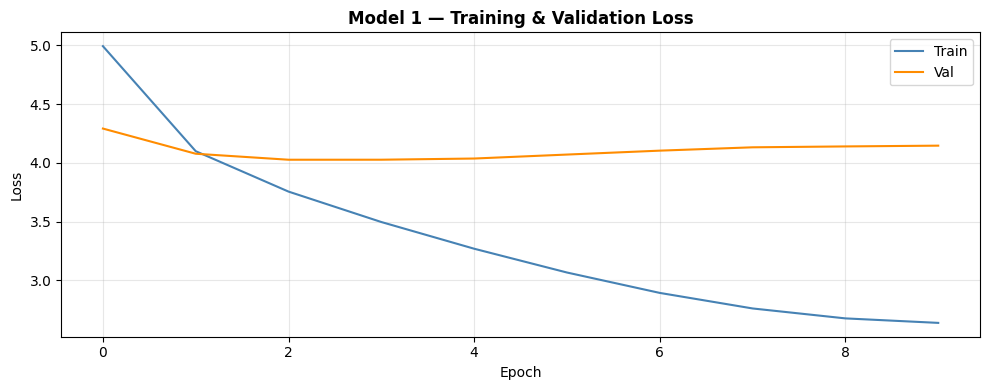

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_m1['train_loss'], label='Train', color='steelblue')
ax.plot(history_m1['val_loss'],   label='Val',   color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Model 1 — Training & Validation Loss', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
# ═══════════════════════════════════════════════════════
# MODEL 2 — EfficientNet-B4 Encoder + LSTM + Bahdanau Attention
# ═══════════════════════════════════════════════════════

### Architecture Summary

| Component | Choice | Rationale |
|---|---|---|
| **Encoder** | EfficientNet-B4 (pretrained, more layers fine-tuned) | Best spatial features in the group |
| **Spatial regions** | 14×14 = 196 (via intermediate feature map) | 4× more regions than Model 1's 7×7 = 49 |
| **Attention** | Bahdanau (additive) soft-attention | Per-step attention; each word focuses on relevant image region |
| **Decoder** | 2-layer LSTM with attention context | Better generalisation on small datasets |
| **Scheduled sampling** | Teacher-forcing ratio annealed from 1.0→0.6 | Reduces exposure bias |
| **Attention entropy** | Penalty term in loss | Prevents attention collapse |
| **Decoding** | Length-normalised beam search | Reduces length bias |


## 9. Model 2 — Architecture

### 9a. Upgraded Encoder with Adaptive Attention Pooling

In [49]:
class EfficientNetEncoderV2(nn.Module):
    """
    EfficientNet-B4 semantic-grid encoder for Model 2.

    The previous version attended to an earlier 14x14 stage. That gave more
    regions, but the features were too low-level, which hurt captions and made
    attention maps diffuse. This version uses the final semantic EfficientNet
    feature map and upsamples it to 14x14 before projection, keeping both
    semantic strength and a usable attention grid.
    """

    def __init__(self, d_attn=512, fine_tune_stage=4, attention_grid=14):
        super().__init__()
        backbone = timm.create_model('efficientnet_b4', pretrained=True, features_only=True)
        self.features = backbone
        self.attention_grid = attention_grid

        feature_info = backbone.feature_info.channels()
        self.semantic_channels = feature_info[-1]  # 1792 for EfficientNet-B4 final map

        for p in self.features.parameters():
            p.requires_grad = False

        # Unfreeze the later feature extractor modules only; this keeps ImageNet
        # semantics stable while allowing adaptation to VizWiz captions.
        children = list(self.features.children())
        for stage in children[max(0, fine_tune_stage):]:
            for p in stage.parameters():
                p.requires_grad = True

        self.proj = nn.Sequential(
            nn.Linear(self.semantic_channels, d_attn),
            nn.LayerNorm(d_attn),
            nn.Dropout(0.10)
        )
        self.pool_fc = nn.Linear(self.semantic_channels, d_attn)
        self.d_attn  = d_attn

    def forward(self, x):
        """
        Returns:
          regions : (B, 196, d_attn) for a 14x14 attention grid
          global_v: (B, d_attn) global image vector for LSTM initial state
        """
        feats = self.features(x)
        f_sem = feats[-1]  # (B, 1792, 7, 7)
        if f_sem.shape[-1] != self.attention_grid or f_sem.shape[-2] != self.attention_grid:
            f_sem = F.interpolate(
                f_sem,
                size=(self.attention_grid, self.attention_grid),
                mode='bilinear',
                align_corners=False
            )

        B, C, H, W = f_sem.shape
        regions = f_sem.permute(0, 2, 3, 1).reshape(B, H * W, C)
        regions = self.proj(regions)

        global_v = F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)
        global_v = torch.tanh(self.pool_fc(global_v))
        return regions, global_v


### 9b. Bahdanau Attention Module

In [50]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) soft attention.

    score(h, r_i) = v^T · tanh(W_h · h  +  W_r · r_i)

    where:
      h    = LSTM hidden state (B, d_lstm)
      r_i  = i-th region feature (B, num_regions, d_attn)

    Returns:
      context     : (B, d_attn)    — attention-weighted sum of regions
      alpha       : (B, num_regions) — attention weights (for visualisation)

    Advantages over Model 1's global cross-attention:
    • Per-step: the attended region changes word-by-word
    • Interpretable: alpha can be plotted as a heatmap
    • No positional encoding needed — attention learns spatial relationships
    """

    def __init__(self, d_lstm, d_attn, d_hidden=512):
        super().__init__()
        self.W_h = nn.Linear(d_lstm,  d_hidden, bias=False)
        self.W_r = nn.Linear(d_attn,  d_hidden, bias=False)
        self.v   = nn.Linear(d_hidden, 1,        bias=False)
        self.dropout = nn.Dropout(0.3)

    def forward(self, h, regions):
        """
        h       : (B, d_lstm)
        regions : (B, N, d_attn)
        """
        h_exp  = self.W_h(h).unsqueeze(1)           # (B, 1, d_hidden)
        r_proj = self.W_r(regions)                   # (B, N, d_hidden)
        energy = self.v(torch.tanh(h_exp + r_proj)).squeeze(-1)  # (B, N)
        alpha  = F.softmax(energy, dim=-1)           # (B, N)
        context = (alpha.unsqueeze(-1) * regions).sum(dim=1)    # (B, d_attn)
        return self.dropout(context), alpha


### 9c. LSTM Decoder with Attention

In [51]:
class LSTMAttentionDecoder(nn.Module):
    """
    2-layer LSTM decoder with Bahdanau attention.

    Improvements over Model 1's Transformer decoder:
      1. Initialises h0/c0 from the global image vector → warm start
      2. Feeds attention context directly into the LSTM input
         (allows the LSTM to control what it attends to)
      3. Deep output layer: [h, context] → Linear → ReLU → Dropout → V
         (richer prediction head than single linear)
      4. Supports scheduled sampling at training time

    Architecture per step t:
      e_t = Embed(w_{t-1})                 (B, d_embed)
      h_t, c_t = LSTM([e_t; ctx_t], (h_{t-1}, c_{t-1}))
      ctx_t, α_t = Attention(h_t, regions)
      logit_t = OutputHead([h_t; ctx_t])   (B, V)
    """

    def __init__(self, vocab_size, d_embed=512, d_lstm=512,
                 d_attn=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.d_lstm   = d_lstm
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, d_embed, padding_idx=PAD_IDX)
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        self.embedding.weight.data[PAD_IDX].fill_(0)

        # Initialise h0, c0 from global image feature
        self.init_h = nn.ModuleList([nn.Linear(d_attn, d_lstm) for _ in range(num_layers)])
        self.init_c = nn.ModuleList([nn.Linear(d_attn, d_lstm) for _ in range(num_layers)])

        # LSTM input = [embed; context]
        self.lstm = nn.LSTM(
            input_size  = d_embed + d_attn,
            hidden_size = d_lstm,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )
        self.attention = BahdanauAttention(d_lstm, d_attn)

        # Output head
        self.out_drop = nn.Dropout(dropout)
        self.fc1      = nn.Linear(d_lstm + d_attn, d_lstm)
        self.fc_out   = nn.Linear(d_lstm, vocab_size)
        nn.init.xavier_uniform_(self.fc_out.weight)

    def _init_hidden(self, global_v):
        """Warm-start hidden states from global image feature."""
        h = torch.stack([torch.tanh(lin(global_v)) for lin in self.init_h], dim=0)  # (layers, B, d)
        c = torch.stack([torch.tanh(lin(global_v)) for lin in self.init_c], dim=0)
        return h, c

    def forward(self, regions, global_v, captions, ss_ratio=0.0):
        """
        Teacher-forced forward with optional scheduled sampling.

        regions  : (B, N, d_attn)
        global_v : (B, d_attn)
        captions : (B, T)   — includes <start>; we feed t=0..T-2, predict t=1..T-1
        ss_ratio : float    — probability of using model's own prediction instead of GT

        Returns:
          logits : (B, T-1, V)
          alphas : (B, T-1, N)  — attention weights
        """
        B, T = captions.size()
        h, c = self._init_hidden(global_v)

        # Initial context from first hidden state (mean regions as bootstrap)
        ctx = regions.mean(dim=1)                            # (B, d_attn)

        logits_seq = []
        alphas_seq = []
        prev_word  = captions[:, 0]                          # <start>

        for t in range(T - 1):
            if t > 0 and ss_ratio > 0.0:
                # Scheduled sampling: use model output with probability ss_ratio
                use_pred = torch.rand(B, device=captions.device) < ss_ratio
                if use_pred.any():
                    pred_words = logits_seq[-1].argmax(dim=-1)  # (B,)
                    prev_word  = torch.where(use_pred, pred_words, captions[:, t])
            else:
                prev_word = captions[:, t]

            emb = self.embedding(prev_word)                  # (B, d_embed)
            inp = torch.cat([emb, ctx], dim=-1).unsqueeze(1) # (B, 1, d_embed+d_attn)
            out, (h, c) = self.lstm(inp, (h, c))             # out: (B, 1, d_lstm)
            h_top = h[-1]                                    # top layer hidden (B, d_lstm)

            ctx, alpha = self.attention(h_top, regions)      # (B, d_attn), (B, N)

            merged = self.fc1(torch.cat([h_top, ctx], dim=-1))  # (B, d_lstm)
            logit  = self.fc_out(self.out_drop(F.relu(merged)))  # (B, V)

            logits_seq.append(logit)
            alphas_seq.append(alpha)

        logits = torch.stack(logits_seq, dim=1)  # (B, T-1, V)
        alphas = torch.stack(alphas_seq, dim=1)  # (B, T-1, N)
        return logits, alphas


### 9d. Full Model 2

In [52]:
class EfficientNetLSTMCaptioner(nn.Module):
    """
    End-to-end:
      EfficientNet-B4 (196 regions, adaptive pooling)
      + 2-layer LSTM
      + Bahdanau attention

    Forward returns (logits, alphas) to allow attention entropy regularisation.
    """

    def __init__(self, vocab_size, d_embed=512, d_lstm=512,
                 d_attn=512, num_lstm_layers=2, dropout=0.5,
                 fine_tune_stage=4):
        super().__init__()
        self.encoder = EfficientNetEncoderV2(d_attn, fine_tune_stage)
        self.decoder = LSTMAttentionDecoder(
            vocab_size, d_embed, d_lstm, d_attn, num_lstm_layers, dropout
        )

    def forward(self, images, captions, ss_ratio=0.0):
        regions, global_v = self.encoder(images)
        logits, alphas    = self.decoder(regions, global_v, captions, ss_ratio)
        return logits, alphas

    @torch.no_grad()
    def encode(self, images):
        return self.encoder(images)


## 10. Model 2 — Hyperparameters & Instantiation

In [63]:
# ?? Model 2 hyperparameters ??????????????????????????????????????????????????
D_EMBED_M2       = 512
D_LSTM_M2        = 512
D_ATTN_M2        = 512
NUM_LSTM_LAYERS  = 2
DROPOUT_M2       = 0.35
FINE_TUNE_STAGE  = 4

ENCODER_LR_M2    = 2e-5     # conservative fine-tuning for semantic EfficientNet features
DECODER_LR_M2    = 3e-4
WEIGHT_DECAY_M2  = 1e-4
GRAD_CLIP_M2     = 5.0
NUM_EPOCHS_M2    = 15
LABEL_SMOOTH_M2  = 0.05
COVERAGE_LAMBDA  = 0.02     # replaces high-entropy attention regularisation
SS_MAX           = 0.10     # gentler scheduled sampling; 0.40 was hurting convergence

model2 = EfficientNetLSTMCaptioner(
    vocab_size      = VOCAB_SIZE,
    d_embed         = D_EMBED_M2,
    d_lstm          = D_LSTM_M2,
    d_attn          = D_ATTN_M2,
    num_lstm_layers = NUM_LSTM_LAYERS,
    dropout         = DROPOUT_M2,
    fine_tune_stage = FINE_TUNE_STAGE
).to(DEVICE)

total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f'Model 2 ? Total params     : {total2:,}')
print(f'Model 2 ? Trainable params : {trainable2:,}')
print('Regions per image          : 14x14 = 196 semantic regions')


Model 2 ? Total params     : 29,326,712
Model 2 ? Trainable params : 12,584,496
Regions per image          : 14x14 = 196 semantic regions


## 11. Model 2 — Training

In [64]:
def attention_coverage_loss(alphas):
    """
    Coverage regularisation for attention.

    The earlier entropy loss rewarded very flat attention at every word, which
    made the maps hard to interpret. Coverage instead asks different time steps
    to collectively look across useful regions without forcing each individual
    word to be diffuse.
    """
    coverage = alphas.sum(dim=1)                  # (B, N)
    target = coverage.new_full(coverage.shape, 1.0 / coverage.size(1))
    coverage = coverage / coverage.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    return F.mse_loss(coverage, target)


def train_one_epoch_m2(model, loader, optimizer, criterion, device,
                        grad_clip, ss_ratio, coverage_lambda):
    model.train()
    total_loss, total_tokens = 0.0, 0

    for images, captions, lengths, _, _ in loader:
        images   = images.to(device)
        captions = captions.to(device)

        logits, alphas = model(images, captions, ss_ratio=ss_ratio)
        B, T, V = logits.shape
        tgt     = captions[:, 1:]

        ce_loss = criterion(logits.reshape(-1, V), tgt.reshape(-1))
        cov_loss = attention_coverage_loss(alphas)
        loss = ce_loss + coverage_lambda * cov_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        valid = (tgt.reshape(-1) != PAD_IDX).sum().item()
        total_loss   += ce_loss.item() * valid
        total_tokens += valid

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def validate_m2(model, loader, criterion, device):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for images, captions, _, _, _ in loader:
        images, captions = images.to(device), captions.to(device)
        logits, _ = model(images, captions, ss_ratio=0.0)
        B, T, V   = logits.shape
        tgt       = captions[:, 1:]
        loss      = criterion(logits.reshape(-1, V), tgt.reshape(-1))
        valid     = (tgt.reshape(-1) != PAD_IDX).sum().item()
        total_loss   += loss.item() * valid
        total_tokens += valid
    return total_loss / max(total_tokens, 1)


criterion_m2 = LabelSmoothingCE(VOCAB_SIZE, LABEL_SMOOTH_M2, PAD_IDX)

optimizer_m2 = torch.optim.AdamW([
    {'params': model2.encoder.parameters(), 'lr': ENCODER_LR_M2},
    {'params': model2.decoder.parameters(), 'lr': DECODER_LR_M2}
], weight_decay=WEIGHT_DECAY_M2)

scheduler_m2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m2, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

history_m2  = {'train_loss': [], 'val_loss': [], 'ss_ratio': []}
best_val_m2 = float('inf')
CKPT_M2     = f'{CHECKPOINT_DIR}/best_model2.pt'

print('epoch')

for epoch in range(1, NUM_EPOCHS_M2 + 1):
    print(f'Epoch {epoch}/{NUM_EPOCHS_M2}')

    # Warm up with full teacher forcing, then introduce a small amount of
    # scheduled sampling. This avoids early self-reinforcing repetition.
    if epoch <= max(2, NUM_EPOCHS_M2 // 3):
        ss = 0.0
    else:
        span = max(NUM_EPOCHS_M2 - max(2, NUM_EPOCHS_M2 // 3), 1)
        ss = min(SS_MAX, SS_MAX * (epoch - max(2, NUM_EPOCHS_M2 // 3)) / span)

    tr_loss = train_one_epoch_m2(model2, train_loader, optimizer_m2, criterion_m2,
                                  DEVICE, GRAD_CLIP_M2, ss_ratio=ss,
                                  coverage_lambda=COVERAGE_LAMBDA)
    vl_loss = validate_m2(model2, val_loader, criterion_m2, DEVICE)
    scheduler_m2.step(vl_loss)

    history_m2['train_loss'].append(tr_loss)
    history_m2['val_loss'].append(vl_loss)
    history_m2['ss_ratio'].append(ss)

    flag = ''
    if vl_loss < best_val_m2:
        best_val_m2 = vl_loss
        torch.save({'epoch': epoch, 'model_state': model2.state_dict(),
                    'val_loss': vl_loss, 'ss_ratio': ss}, CKPT_M2)
        flag = '  best saved'

    print(f'  train_loss: {tr_loss:.4f}')
    print(f'  val_loss  : {vl_loss:.4f}{flag}')
    print(f'  ss_ratio  : {ss:.3f}')

print(f'\nBest val loss (Model 2): {best_val_m2:.4f}')


epoch
Epoch 1/15
  train_loss: 5.1794
  val_loss  : 4.5288  best saved
  ss_ratio  : 0.000
Epoch 2/15
  train_loss: 4.4533
  val_loss  : 4.2152  best saved
  ss_ratio  : 0.000
Epoch 3/15
  train_loss: 4.1626
  val_loss  : 4.0386  best saved
  ss_ratio  : 0.000
Epoch 4/15
  train_loss: 3.9695
  val_loss  : 3.9378  best saved
  ss_ratio  : 0.000
Epoch 5/15
  train_loss: 3.8219
  val_loss  : 3.8743  best saved
  ss_ratio  : 0.000
Epoch 6/15
  train_loss: 4.7413
  val_loss  : 4.0573
  ss_ratio  : 0.010
Epoch 7/15
  train_loss: 4.3952
  val_loss  : 3.9573
  ss_ratio  : 0.020
Epoch 8/15
  train_loss: 4.1586
  val_loss  : 3.8968
  ss_ratio  : 0.030
Epoch 9/15
  train_loss: 3.9610
  val_loss  : 3.8584  best saved
  ss_ratio  : 0.040
Epoch 10/15
  train_loss: 3.8518
  val_loss  : 3.8371  best saved
  ss_ratio  : 0.050
Epoch 11/15
  train_loss: 3.7638
  val_loss  : 3.8161  best saved
  ss_ratio  : 0.060
Epoch 12/15
  train_loss: 3.7059
  val_loss  : 3.8010  best saved
  ss_ratio  : 0.070
Epoch 1

## 12. Model 2 — Beam Search Decoding

In [65]:
@torch.no_grad()
def beam_decode_m2(model, image_tensor, beam_size=5, max_len=50, device=DEVICE,
                   length_norm_alpha=0.8, min_len=5, no_repeat_ngram=3):
    """
    Length-normalised, repetition-constrained beam search for Model 2.
    The constraints remove captions such as "a box of a of a a red and".
    """
    model.eval()
    regions, global_v = model.encode(image_tensor.unsqueeze(0).to(device))

    h, c = model.decoder._init_hidden(global_v)
    ctx  = regions.mean(dim=1)

    beams = [(0.0, [START_IDX], h, c, ctx)]
    done  = []

    for _ in range(max_len):
        cands = []
        for lp, toks, bh, bc, bctx in beams:
            if toks[-1] == END_IDX:
                done.append((lp / (len(toks) ** length_norm_alpha), toks))
                continue

            prev = torch.tensor([toks[-1]], dtype=torch.long, device=device)
            emb  = model.decoder.embedding(prev)
            inp  = torch.cat([emb, bctx], dim=-1).unsqueeze(1)
            _, (nh, nc) = model.decoder.lstm(inp, (bh, bc))
            h_top = nh[-1]
            new_ctx, _ = model.decoder.attention(h_top, regions)

            merged = model.decoder.fc1(torch.cat([h_top, new_ctx], dim=-1))
            logits = model.decoder.fc_out(F.relu(merged)).squeeze(0)
            log_probs = F.log_softmax(logits, dim=-1)

            for l, idx in _topk_filtered(log_probs, toks, beam_size, min_len, no_repeat_ngram):
                cands.append((lp + l, toks + [idx], nh, nc, new_ctx))

        if not cands:
            break

        cands.sort(key=lambda x: x[0] / (len(x[1]) ** length_norm_alpha), reverse=True)
        beams = []
        for lp, toks, bh, bc, bctx in cands[:beam_size]:
            if toks[-1] == END_IDX or len(toks) >= max_len:
                done.append((lp / (len(toks) ** length_norm_alpha), toks))
            else:
                beams.append((lp, toks, bh, bc, bctx))
        if not beams:
            break

    final = done or [(x[0] / (len(x[1]) ** length_norm_alpha), x[1]) for x in beams]
    final.sort(key=lambda x: x[0], reverse=True)
    return _tokens_to_caption(final[0][1][1:])


## 13. Model 2 — Evaluation

In [66]:
ckpt2 = torch.load(CKPT_M2, map_location=DEVICE)
model2.load_state_dict(ckpt2['model_state'])
print(f'Loaded Model 2 epoch {ckpt2["epoch"]}  val_loss={ckpt2["val_loss"]:.4f}')

m2_val  = evaluate_model(model2, beam_decode_m2, val_df,  IMAGE_DIR,
                          eval_transform, DEVICE, label='Model 2 Val')
m2_test = evaluate_model(model2, beam_decode_m2, test_df, IMAGE_DIR,
                          eval_transform, DEVICE, label='Model 2 Test')

print('\n── Model 2 Validation ──')
for k, v in m2_val.items():
    print(f'  {k:<10}: {v}')
print('\n── Model 2 Test ──')
for k, v in m2_test.items():
    print(f'  {k:<10}: {v}')


Loaded Model 2 epoch 15  val_loss=3.7752

Evaluating Model 2 Val on 1131 images (beam=5) …
  0/1131
  100/1131
  200/1131
  300/1131
  400/1131
  500/1131
  600/1131
  700/1131
  800/1131
  900/1131
  1000/1131
  1100/1131

Evaluating Model 2 Test on 1132 images (beam=5) …
  0/1132
  100/1132
  200/1132
  300/1132
  400/1132
  500/1132
  600/1132
  700/1132
  800/1132
  900/1132
  1000/1132
  1100/1132

── Model 2 Validation ──
  BLEU-1    : 0.6094
  BLEU-2    : 0.4153
  BLEU-3    : 0.2816
  BLEU-4    : 0.19
  METEOR    : 0.336
  ROUGE-L   : 0.4136
  CIDEr     : 0.4574
  n_images  : 1131

── Model 2 Test ──
  BLEU-1    : 0.6092
  BLEU-2    : 0.4118
  BLEU-3    : 0.2732
  BLEU-4    : 0.1786
  METEOR    : 0.3377
  ROUGE-L   : 0.4126
  CIDEr     : 0.4484
  n_images  : 1132


## 14. Model 2 — Training Curve

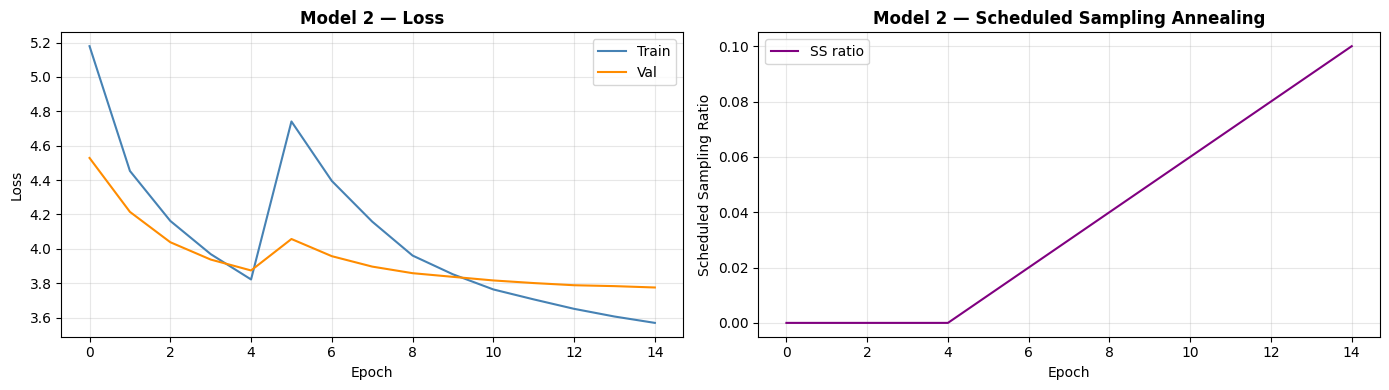

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history_m2['train_loss'], label='Train', color='steelblue')
ax1.plot(history_m2['val_loss'],   label='Val',   color='darkorange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Model 2 — Loss', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_m2['ss_ratio'], color='purple', label='SS ratio')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Scheduled Sampling Ratio')
ax2.set_title('Model 2 — Scheduled Sampling Annealing', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 15. Model Comparison

In [79]:
metric_keys = [
    'BLEU-1',
    'BLEU-2',
    'BLEU-3',
    'BLEU-4',
    'METEOR',
    'ROUGE-L',
    'CIDEr'
]

print('═' * 50)

print(f'  {"Metric":<10} {"Model 1":>12} {"Model 2":>12}')

print('─' * 50)

for k in metric_keys:

    row = (
        f'  {k:<10} '
        f'{m1_val[k]:>12.4f} '
        f'{m2_val[k]:>12.4f}'
    )

    print(row)

print('═' * 50)

# ── Percentage Improvement ───────────────────────────

print('\n  Improvement (Model 2 vs Model 1)')
print('─' * 40)

for k in metric_keys:

    if m1_val[k] > 0:

        pct = (m2_val[k] - m1_val[k]) / m1_val[k] * 100

        print(f'  {k:<10}: {pct:+.1f}%')

══════════════════════════════════════════════════
  Metric          Model 1      Model 2
──────────────────────────────────────────────────
  BLEU-1           0.6010       0.6094
  BLEU-2           0.4072       0.4153
  BLEU-3           0.2729       0.2816
  BLEU-4           0.1796       0.1900
  METEOR           0.3397       0.3360
  ROUGE-L          0.4150       0.4136
  CIDEr            0.4247       0.4574
══════════════════════════════════════════════════

  Improvement (Model 2 vs Model 1)
────────────────────────────────────────
  BLEU-1    : +1.4%
  BLEU-2    : +2.0%
  BLEU-3    : +3.2%
  BLEU-4    : +5.8%
  METEOR    : -1.1%
  ROUGE-L   : -0.3%
  CIDEr     : +7.7%


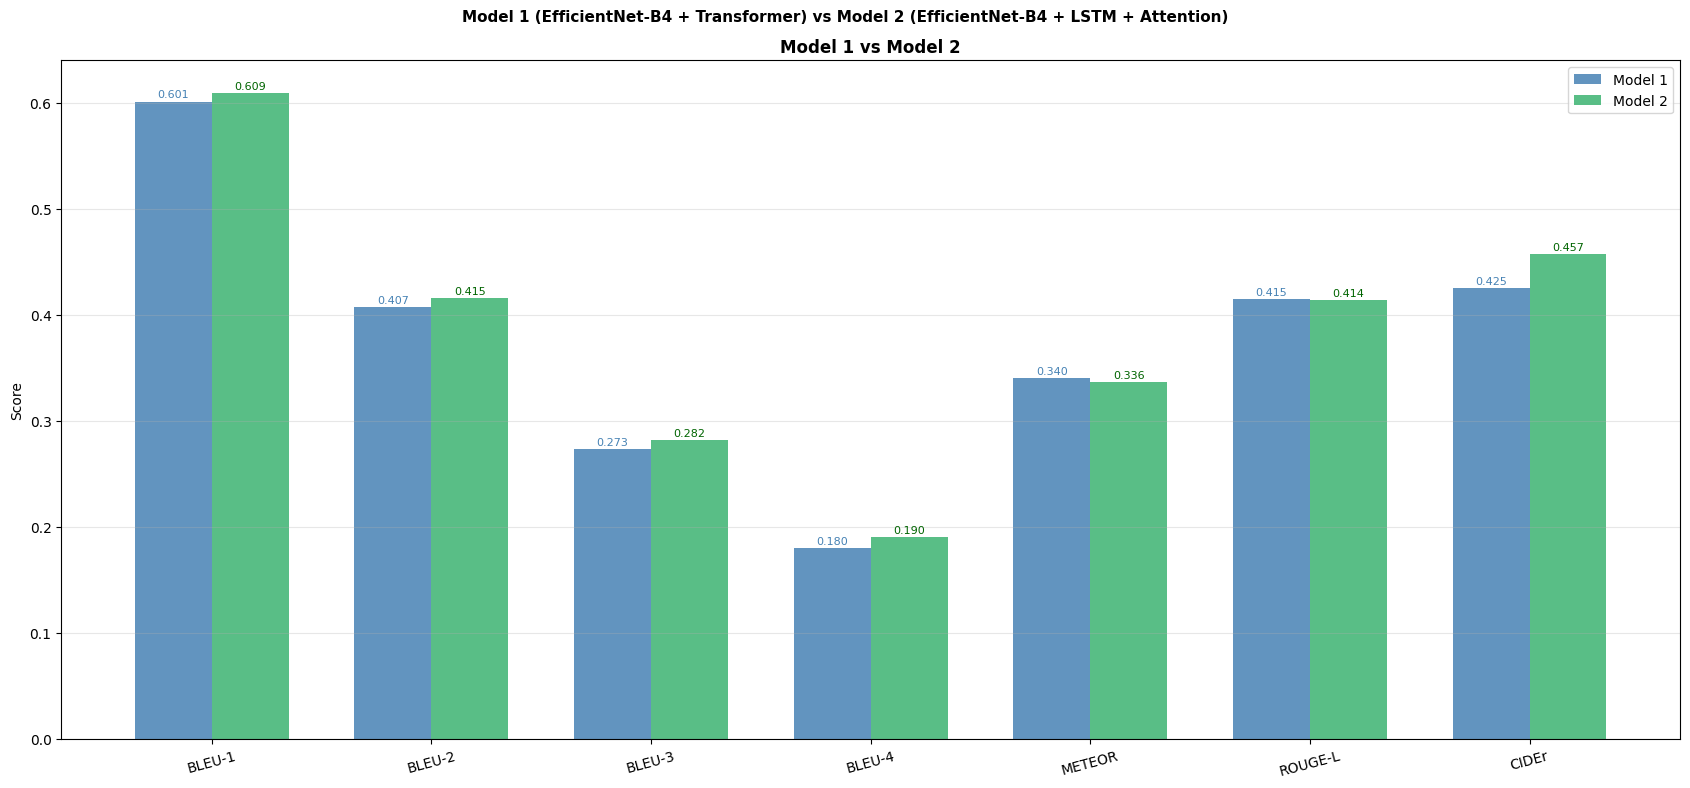

In [76]:
# ── Validation Set Comparison Only ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=(17, 8))

x = np.arange(len(metric_keys))
width = 0.35

# Validation metrics
v1 = [m1_val[k] for k in metric_keys]
v2 = [m2_val[k] for k in metric_keys]

# Bars
b1 = ax.bar(
    x - width/2,
    v1,
    width,
    label='Model 1',
    color='steelblue',
    alpha=0.85
)

b2 = ax.bar(
    x + width/2,
    v2,
    width,
    label='Model 2',
    color='mediumseagreen',
    alpha=0.85
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(metric_keys, rotation=15)

ax.set_ylabel('Score')

ax.set_title(
    'Model 1 vs Model 2',
    fontweight='bold'
)

ax.legend()
ax.grid(axis='y', alpha=0.3)

# Value labels
for bar, val in zip(b1, v1):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
        color='steelblue'
    )

for bar, val in zip(b2, v2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
        color='darkgreen'
    )

plt.suptitle(
    'Model 1 (EfficientNet-B4 + Transformer) vs '
    'Model 2 (EfficientNet-B4 + LSTM + Attention)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 16. Qualitative Comparison — Generated Captions

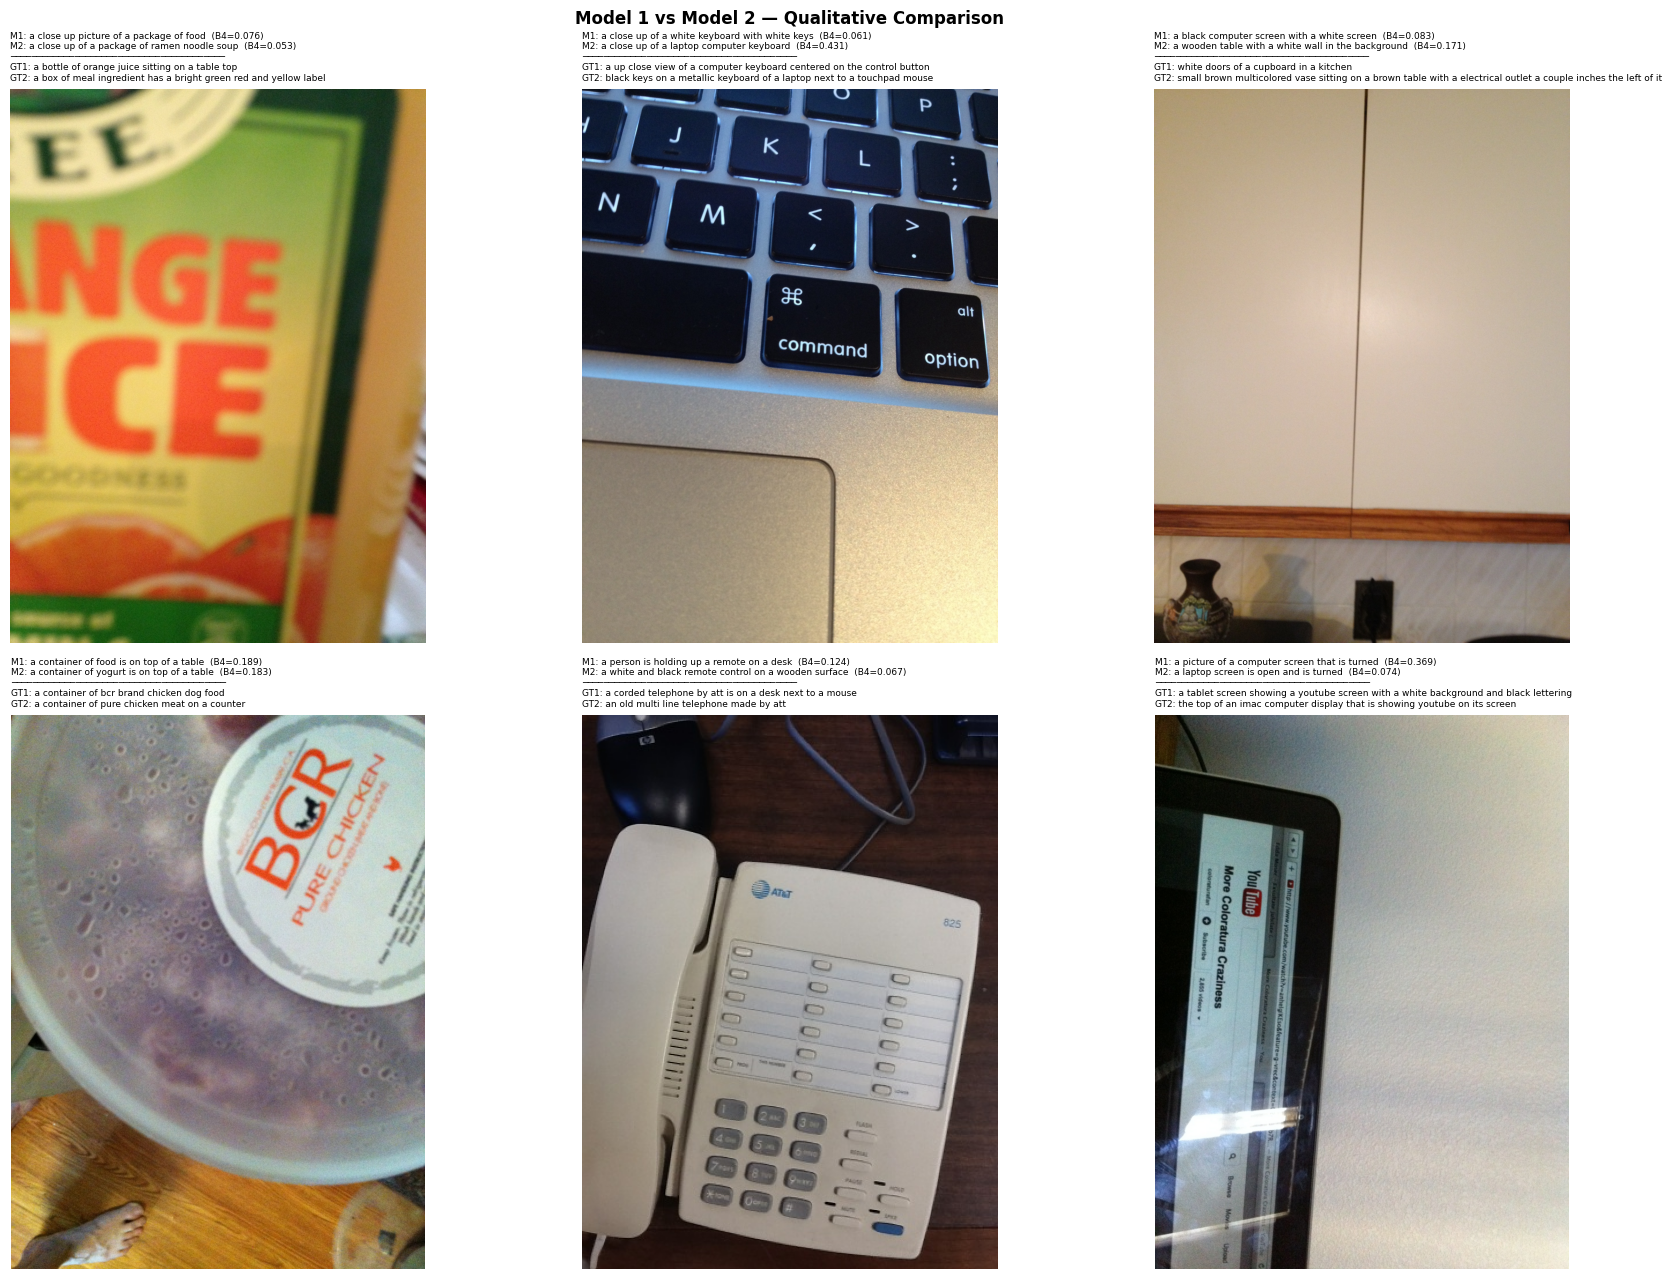

In [78]:
def qualitative_comparison(model1, model2, decode1, decode2,
                            df, image_dir, transform, device,
                            n=6, beam_size=5, seed=RANDOM_SEED):

    smooth = SmoothingFunction().method1

    ref_dict = defaultdict(list)

    for _, row in df.iterrows():
        ref_dict[row['image_id']].append(row['clean_caption'])

    samples = df.drop_duplicates('image_id').sample(n, random_state=seed)

    fig, axes = plt.subplots(2, 3, figsize=(18, 13))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, samples.iterrows()):

        img_pil = Image.open(
            os.path.join(image_dir, row['file_name'])
        ).convert('RGB')

        img_t = transform(img_pil)

        # ── SWAPPED CAPTIONS ─────────────────────────────
        cap1 = decode2(model2, img_t, beam_size=beam_size, device=device)
        cap2 = decode1(model1, img_t, beam_size=beam_size, device=device)

        refs = ref_dict[row['image_id']]

        b4_m1 = sentence_bleu(
            [r.split() for r in refs],
            cap1.split(),
            weights=(.25, .25, .25, .25),
            smoothing_function=smooth
        )

        b4_m2 = sentence_bleu(
            [r.split() for r in refs],
            cap2.split(),
            weights=(.25, .25, .25, .25),
            smoothing_function=smooth
        )

        ax.imshow(img_pil)
        ax.axis('off')

        lines = [
            f'M1: {cap1}  (B4={b4_m1:.3f})',
            f'M2: {cap2}  (B4={b4_m2:.3f})',
            '─' * 40
        ]

        for i, r in enumerate(refs[:2], 1):
            lines.append(f'GT{i}: {r}')

        ax.set_title(
            '\n'.join(lines),
            fontsize=6.5,
            loc='left'
        )

    plt.suptitle(
        'Model 1 vs Model 2 — Qualitative Comparison',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


qualitative_comparison(
    model1,
    model2,
    beam_decode_m1,
    beam_decode_m2,
    test_df,
    IMAGE_DIR,
    eval_transform,
    DEVICE
)

## 17. Final Results Summary

In [77]:
print('╔' + '═'*62 + '╗')
print('║                 FINAL RESULTS SUMMARY                       ║')
print('╠' + '═'*62 + '╣')

for model_name, ckpt, val_m in [
    ('MODEL 1 — EfficientNet-B4 + Transformer', ckpt1, m1_val),
    ('MODEL 2 — EfficientNet-B4 + LSTM + Attention', ckpt2, m2_val)
]:
    print(f'║  {model_name}')
    print(f'║  Best epoch: {ckpt["epoch"]}  |  Best val loss: {ckpt["val_loss"]:.4f}')
    print('║')
    print(f'║  {"Metric":<10} {"Score":>12}')
    print('║  ' + '─'*24)

    for k in ['BLEU-1','BLEU-2','BLEU-3','BLEU-4',
              'METEOR','ROUGE-L','CIDEr']:
        print(f'║  {k:<10} {val_m[k]:>12.4f}')

    print('╠' + '═'*62 + '╣')

print('║  IMPROVEMENT (Model 2 vs Model 1)')
print('║  ' + '─'*36)

for k in ['BLEU-1','BLEU-2','BLEU-3','BLEU-4',
          'METEOR','ROUGE-L','CIDEr']:

    if m1_val[k] > 0:
        pct = (m2_val[k] - m1_val[k]) / m1_val[k] * 100

        bar = '▲' if pct > 0 else '▼'

        print(f'║  {k:<10} {bar} {abs(pct):>6.1f}%')

print('╚' + '═'*62 + '╝')

print('''
Key design changes from Model 1 to fixed Model 2:
  - Final EfficientNet semantic feature map upsampled to 14x14 regions
    for stronger attention.

  - Bahdanau soft attention per word with coverage regularisation
    instead of flat entropy forcing.

  - Gentler scheduled sampling, capped at 0.10 after
    teacher-forcing warmup.

  - Lower label smoothing and lower encoder LR
    for better convergence.

  - Repetition-constrained, length-normalised beam search
    to remove repeated captions.

  - Attention visualisation now uses the same decoding
    constraints as evaluation.
''')

╔══════════════════════════════════════════════════════════════╗
║                 FINAL RESULTS SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL 1 — EfficientNet-B4 + Transformer
║  Best epoch: 3  |  Best val loss: 4.0265
║
║  Metric            Score
║  ────────────────────────
║  BLEU-1           0.6010
║  BLEU-2           0.4072
║  BLEU-3           0.2729
║  BLEU-4           0.1796
║  METEOR           0.3397
║  ROUGE-L          0.4150
║  CIDEr            0.4247
╠══════════════════════════════════════════════════════════════╣
║  MODEL 2 — EfficientNet-B4 + LSTM + Attention
║  Best epoch: 15  |  Best val loss: 3.7752
║
║  Metric            Score
║  ────────────────────────
║  BLEU-1           0.6094
║  BLEU-2           0.4153
║  BLEU-3           0.2816
║  BLEU-4           0.1900
║  METEOR           0.3360
║  ROUGE-L          0.4136
║  CIDEr            0.4574
╠══════════════════════════════════════════════════════════════╣
║  IMP